In [1]:
import warnings
warnings.filterwarnings('ignore')

(Tutorial_Get_hbonds)=
# Get attributed hydrogen bonds

*Calculating sparse observations with named hydrogen-bond criteria.*

Each relation has three singleton roles: donor, hydrogen and acceptor.
Choose a known criterion explicitly and retain its method reference, producer software,
units, evaluated coverage and observed periodic images. Buch and Luzard–Chandler
remain available with their existing defaults.

:::{versionadded} 1.0.0
:::

:::{admonition} API documentation
:class: dropdown

See {func}`molsysmt.interactions.hbonds.get_hbonds` for arguments, units, outputs and errors.
:::

## Basic usage

Let's show how this function works with a controlled water-pair ensemble, including
one structure with no accepted observations. This demonstrates geometry and coverage,
not thermodynamic stability of the supplied coordinates.

In [2]:
import molsysmt as msm

In [3]:
import numpy as np
from rdkit import Chem
from molsysmt import pyunitwizard as puw

molsys = msm.convert(Chem.AddHs(Chem.MolFromSmiles('O.O')), to_form='molsysmt.MolSys')
xyz = np.array([[0, 0, 0], [.28, 0, 0], [.1, 0, 0], [0, .1, 0], [.28, .1, 0], [.28, 0, .1]])
coordinates = np.repeat(xyz[None], 3, axis=0)
coordinates[1, [1, 4, 5]] += [0, .4, 0]
molsys.structures.append(coordinates=puw.quantity(coordinates, 'nm'))

In [4]:
analysis = msm.interactions.hbonds.get_hbonds(molsys, pbc=False)
print(analysis.occurrence_structures.tolist())
print(analysis.evaluated_structure_indices.tolist())
print(analysis.relation(0))
assert analysis.occurrence_structures.tolist() == [0, 2]

[0, 2]
[0, 1, 2]
{'interaction_type': 'hbond', 'participants': [{'role': 'donor', 'atom_indices': array([0])}, {'role': 'hydrogen', 'atom_indices': array([2])}, {'role': 'acceptor', 'atom_indices': array([1])}]}


## Choosing the scientific criterion

DA denotes donor–acceptor distance; HA denotes hydrogen–acceptor distance.
DHA is the angle at H and HDA is the angle at D, zero for a straight D–H…A arrangement.

| Method | Default geometry | Site recognition |
| --- | --- | --- |
| baker_hubbard | HA <0.25 nm; DHA >120° | MDTraj N/O rules |
| wernet_nilsson | DA <0.33 nm −0.000044 nm/degree² × HDA² | MDTraj N/O rules |
| cpptraj | DA ≤0.30 nm; DHA ≥135° | CPPTRAJ F/O/N rules |
| prolif | DA ≤0.35 nm; DHA ≥130° | ProLIF 2.2.2 SMARTS |
| mdanalysis_geometry | 0.10 nm < DA ≤0.30 nm; DHA >150° | Explicit sites required |

These are individual observations per structure. No occupancy/frequency, solvent,
sidechain, energy or water-bridge filter is applied. CPPTRAJ source comparisons are
inclusive despite its help text. Wernet–Nilsson follows MDTraj's implemented curve;
its literal extra comparison with 45 is in radians, not a 45° angular cutoff.

In [5]:
profiles = {method: msm.interactions.hbonds.get_hbonds(molsys, method=method, pbc=False)
            for method in ('baker_hubbard', 'wernet_nilsson', 'cpptraj', 'prolif')}
explicit = msm.interactions.hbonds.get_hbonds(
    molsys, method='mdanalysis_geometry', donor_hydrogen_pairs=[[0, 2]],
    acceptor_atom_indices=[1], pbc=False)
print({method: result.n_interactions for method, result in profiles.items()})
print(explicit.parameters['method_reference'])

{'baker_hubbard': 2, 'wernet_nilsson': 2, 'cpptraj': 2, 'prolif': 2}
{'software': 'MDAnalysis', 'commit': '9531c6e157d0211bfcc086374e3da429d1e3c8d1', 'implementation': 'https://github.com/MDAnalysis/mdanalysis/blob/9531c6e157d0211bfcc086374e3da429d1e3c8d1/package/MDAnalysis/analysis/hydrogenbonds/hbond_analysis.py', 'documentation': 'https://docs.mdanalysis.org/stable/documentation_pages/analysis/hydrogenbonds.html'}


## Inspecting structural observations

Measure columns align with occurrences. All distances are stored in nm and both
angles in radians, independent of the session's preferred display units.

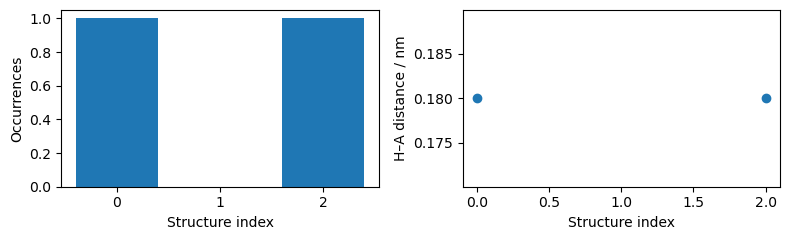

In [6]:
import matplotlib.pyplot as plt
counts = [analysis.query(structure_indices=i).n_interactions for i in range(3)]
fig, axes = plt.subplots(1, 2, figsize=(8, 2.5))
axes[0].bar(range(3), counts)
axes[0].set(xlabel='Structure index', ylabel='Occurrences', xticks=range(3))
axes[1].plot(analysis.occurrence_structures, analysis.measurements['hydrogen_acceptor_distance'], 'o')
axes[1].set(xlabel='Structure index', ylabel='H–A distance / nm')
fig.tight_layout()

## Combining structure and atom selections

Repeated structure indices are evaluated once in sorted order. Internal calculations
require all three atoms in S; incident calculations require any role in S. Between
calculations require all atoms in the union of disjoint selections and at least one
in each. A selected hydrogen therefore counts as participation.

In [7]:
selected = msm.interactions.hbonds.get_hbonds(molsys, structure_indices=[2, 0, 2], pbc=False)
internal = msm.interactions.hbonds.get_hbonds(molsys, selection=[0, 2], pbc=False)
incident = msm.interactions.hbonds.get_hbonds(molsys, selection=[2], selection_mode='incident', pbc=False)
between = msm.interactions.hbonds.get_hbonds(molsys, selection=[0, 2], selection_2=[1], selection_mode='between', pbc=False)
assert (internal.n_interactions, incident.n_interactions, between.n_interactions) == (0, 2, 2)
print(selected.evaluated_structure_indices.tolist())
print(analysis.query(atom_indices=[2], structure_indices=[2, 0]).to_dict()['occurrence_indices'])
assert analysis.query(structure_indices=1).n_interactions == 0

[0, 2]
[1 0]


## Changing unitful cutoffs

Use unit-bearing strings or PyUnitWizard quantities. Wernet–Nilsson permits changing
the curve's distance intercept but rejects a separate angle threshold. Supplying
explicit sites overrides recognition and records that caller declaration.

In [8]:
with puw.context(standard_units=['angstrom', 'degrees', 'ps', 'e']):
    changed = msm.interactions.hbonds.get_hbonds(
        molsys, distance_threshold='2.5 angstrom', angle_threshold='120 degrees', pbc=False)
print(changed.measure_units)
assert changed.measure_units['dha_angle'] == 'radians'

{'donor_hydrogen_distance': 'nm', 'donor_acceptor_distance': 'nm', 'hydrogen_acceptor_distance': 'nm', 'dha_angle': 'radians', 'hda_angle': 'radians'}


## Retaining the observed periodic image

Box vectors are rows. Reconstruct each participant as raw coordinates plus
`image_vector @ box`; donor has zero image. At-H criteria use donor–H and H–acceptor
MIC vectors; Wernet–Nilsson anchors both vectors at donor. DA profiles fail if
independent DA and H-centered images cannot describe one coherent triplet.
CPPTRAJ additionally requires a whole donor–H pair, matching its original raw vector.

In [9]:
periodic = msm.extract(molsys, structure_indices=[0])
box = np.eye(3)
xyz_pbc = xyz.copy() + [.86, 0, 0]
xyz_pbc[[1, 4, 5]] -= box[0]
msm.set(periodic, coordinates=puw.quantity(xyz_pbc[None], 'nm'), box=puw.quantity(box[None], 'nm'))
observed = msm.interactions.hbonds.get_hbonds(periodic)
print(observed.image_vectors)
triplet = xyz_pbc[observed.participant_atoms] + observed.image_vectors @ box
assert np.isclose(np.linalg.norm(triplet[2]-triplet[1]), observed.measurements['hydrogen_acceptor_distance'][0])

[[0 0 0]
 [0 0 0]
 [1 0 0]]


## Examining a biological system

The bundled Trp-Cage structure includes indexed hydrogens. Elemental Baker–Hubbard
recognition uses its declared graph; these observations do not imply universal
acceptor chemistry or favorable interaction energy.

In [10]:
protein = Chem.MolFromPDBFile(str(msm.systems['Trp-Cage']['1l2y.pdb']), removeHs=False)
biological = msm.interactions.hbonds.get_hbonds(protein, pbc=False)
print(biological.n_interactions, biological.evaluated_structure_indices.tolist())

490 [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37]


:::{note}
:class: dropdown

**Demo Systems Catalog**

See {ref}`Demo Systems <user-foundations-entrance-demo-systems>` for bundled datasets.
:::

## Returning, attaching and saving analyses

The typed dictionary preserves sparse columns, provenance and units. Attachment is
explicit and named; other analyses are retained. See {ref}`Cookbook_Saving_hbond_interactions`
for persistence and remapping through public H5MSM conversion.

In [11]:
columns = msm.interactions.hbonds.get_hbonds(molsys, output_type='molsysmt.InteractionsDict', pbc=False)
restored = msm.convert(columns, to_form='molsysmt.Interactions')
molsys.interactions = {**molsys.interactions, 'water_hbonds': analysis}
assert restored.n_interactions == analysis.n_interactions
print(list(molsys.interactions), analysis.software)

['water_hbonds'] {'molsysmt': '0.21.0+606.ga03eb4bf6'}


## Processing coordinate blocks

Native and H5MSM coordinate routes project required atoms and frames. Other supported
forms use ordinary getters within the eager estimate. Rich H5MSM selections require
eager materialization; index selections permit the projected route. The sparse result
stays resident in RAM, and candidate/result estimates can fail explicitly. Neither
chunk size nor the working budget caps process RSS or caller-owned coordinates.

In [12]:
with msm.configure.context(chunk_size=1):
    blocked = msm.interactions.hbonds.get_hbonds(molsys, heavy_mode='force', pbc=False)
assert blocked.occurrence_structures.tolist() == analysis.occurrence_structures.tolist()
print(blocked.parameters['execution_chunks'])

3


:::{seealso}
:class: dropdown

**Related Tools & References**

- {ref}`Getting hydrogen-bond sites <Tutorial_Get_hbond_sites>` — chemical candidates,
  {func}`molsysmt.physchem.get_hbond_sites`.
- {ref}`Cookbook_Saving_hbond_interactions` — naming, persistence and remapping.
- [MDTraj Baker–Hubbard](https://mdtraj.readthedocs.io/en/latest/api/generated/mdtraj.baker_hubbard.html)
  and [Wernet–Nilsson](https://mdtraj.readthedocs.io/en/latest/api/generated/mdtraj.wernet_nilsson.html).
- [CPPTRAJ hydrogen bonds](https://amberhub.chpc.utah.edu/hbond/).
- [ProLIF interaction definitions](https://prolif.readthedocs.io/en/latest/source/modules/interaction-fingerprint.html).
- [Baker and Hubbard, 1984](https://doi.org/10.1016/0079-6107(84)90007-5)
  and [Wernet et al., 2004](https://doi.org/10.1126/science.1096205) — criterion references.
:::